### Dataset used in this notebook
https://www.kaggle.com/datasets/ananthu017/emotion-detection-fer

In [1]:
!unzip '/content/emotions.zip' -d '/content/dataset'

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/train/sad/im37.png  
  inflating: /content/dataset/train/sad/im370.png  
  inflating: /content/dataset/train/sad/im3700.png  
  inflating: /content/dataset/train/sad/im3701.png  
  inflating: /content/dataset/train/sad/im3702.png  
  inflating: /content/dataset/train/sad/im3703.png  
  inflating: /content/dataset/train/sad/im3704.png  
  inflating: /content/dataset/train/sad/im3705.png  
  inflating: /content/dataset/train/sad/im3706.png  
  inflating: /content/dataset/train/sad/im3707.png  
  inflating: /content/dataset/train/sad/im3708.png  
  inflating: /content/dataset/train/sad/im3709.png  
  inflating: /content/dataset/train/sad/im371.png  
  inflating: /content/dataset/train/sad/im3710.png  
  inflating: /content/dataset/train/sad/im3711.png  
  inflating: /content/dataset/train/sad/im3712.png  
  inflating: /content/dataset/train/sad/im3713.png  
  inflating: /content/dataset/train/sad/im3714.png  

In [2]:
import sys
print(sys.version)

3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [4]:
# !pip uninstall -y mediapipe
# !pip cache purge
# !pip install mediapipe

In [5]:
import mediapipe
print(mediapipe.__version__)
print(dir(mediapipe))
print(dir(mediapipe.tasks.vision))

0.10.31
['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']
['FaceDetector', 'FaceDetectorOptions', 'FaceDetectorResult', 'FaceLandmarker', 'FaceLandmarkerOptions', 'FaceLandmarkerResult', 'FaceLandmarksConnections', 'GestureRecognizer', 'GestureRecognizerOptions', 'GestureRecognizerResult', 'HandLandmarker', 'HandLandmarkerOptions', 'HandLandmarkerResult', 'HandLandmarksConnections', 'ImageClassifier', 'ImageClassifierOptions', 'ImageClassifierResult', 'ImageEmbedder', 'ImageEmbedderOptions', 'ImageEmbedderResult', 'ImageProcessingOptions', 'ImageSegmenter', 'ImageSegmenterOptions', 'InteractiveSegmenter', 'InteractiveSegmenterOptions', 'InteractiveSegmenterRegionOfInterest', 'ObjectDetector', 'ObjectDetectorOptions', 'ObjectDetectorResult', 'PoseLandmarker', 'PoseLandmarkerOptions', 'PoseLandmarkerResult', 'PoseLandmarksConnections', 'RunningMode', '__builtins__', '__cac

In [6]:
!wget https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task

--2025-12-22 13:35:45--  https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.137.207, 142.250.141.207, 142.250.101.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.137.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3758596 (3.6M) [application/octet-stream]
Saving to: ‘face_landmarker.task’

face_landmarker.tas 100%[===================>]   3.58M  --.-KB/s    in 0.04s   

2025-12-22 13:35:45 (95.0 MB/s) - ‘face_landmarker.task’ saved [3758596/3758596]



In [8]:
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks.python import BaseOptions


# Initialize ONCE
options = vision.FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path="/content/face_landmarker.task"),
    num_faces=1,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False
)

face_landmarker = vision.FaceLandmarker.create_from_options(options)
def get_face_landmarks(image, draw=False, static_image_mode=True):
    if image is None:
        return []

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # ✅ THIS is the correct constructor for your version
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb
    )

    result = face_landmarker.detect(mp_image)

    if not result.face_landmarks:
        return []

    landmarks = result.face_landmarks[0]

    coords = np.array([[lm.x, lm.y, lm.z] for lm in landmarks])
    coords -= coords.min(axis=0)   # same normalization as before

    return coords.flatten().tolist()

In [9]:
train_dir = '/content/dataset/train'
test_dir = '/content/dataset/test'

In [10]:
import os
os.listdir(train_dir)

['sad', 'fearful', 'happy', 'neutral', 'disgusted', 'angry', 'surprised']

In [11]:
os.listdir(os.path.join(train_dir,'angry'))

['im2520.png',
 'im563.png',
 'im3351.png',
 'im301.png',
 'im2257.png',
 'im1535.png',
 'im159.png',
 'im881.png',
 'im762.png',
 'im3077.png',
 'im2165.png',
 'im922.png',
 'im56.png',
 'im3471.png',
 'im1287.png',
 'im1924.png',
 'im2877.png',
 'im3764.png',
 'im2329.png',
 'im2236.png',
 'im3545.png',
 'im2628.png',
 'im2056.png',
 'im3703.png',
 'im3639.png',
 'im568.png',
 'im3095.png',
 'im3505.png',
 'im543.png',
 'im1024.png',
 'im2055.png',
 'im2010.png',
 'im996.png',
 'im1314.png',
 'im2675.png',
 'im2695.png',
 'im1737.png',
 'im2669.png',
 'im2889.png',
 'im1560.png',
 'im507.png',
 'im1888.png',
 'im723.png',
 'im3757.png',
 'im3881.png',
 'im1955.png',
 'im1787.png',
 'im78.png',
 'im1352.png',
 'im474.png',
 'im2562.png',
 'im3603.png',
 'im414.png',
 'im2760.png',
 'im3361.png',
 'im784.png',
 'im2103.png',
 'im3628.png',
 'im810.png',
 'im1844.png',
 'im827.png',
 'im637.png',
 'im2871.png',
 'im1691.png',
 'im270.png',
 'im1266.png',
 'im1492.png',
 'im567.png',
 'i

In [12]:
sample_img_path = os.path.join(train_dir,'angry','im1088.png')

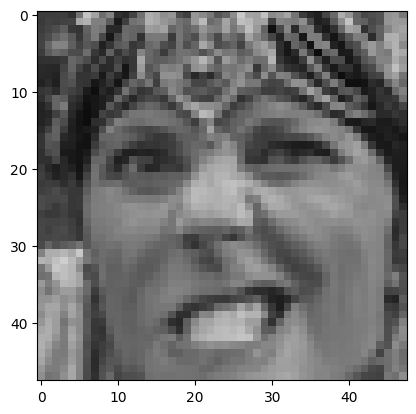

In [13]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(sample_img_path).convert("RGB")
plt.imshow(img)

In [14]:
import os

import cv2
import numpy as np

In [15]:
output = []


for emotion_idx,emotion in enumerate(sorted(os.listdir(train_dir))):
  for image in os.listdir(os.path.join(train_dir,emotion)):
    image_path = os.path.join(train_dir,emotion,image)
    img = cv2.imread(image_path)
    face_landmarks = get_face_landmarks(img)
    if len(face_landmarks) == 1434: # check len before assigning
      face_landmarks.append(int(emotion_idx))
      output.append(face_landmarks)

np.savetxt('data.txt', np.asarray(output))

In [16]:
import pickle

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load data from the text file
data_file = "data.txt"
data = np.loadtxt(data_file)

# Split data into features (X) and labels (y)
X = data[:, :-1]  # Features are all columns except the last one
y = data[:, -1]   # Labels are the last column

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    shuffle=True,
                                                    stratify=y)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier()

# Train the classifier on the training data
rf_classifier.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_classifier.predict(X_test)

# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(confusion_matrix(y_test, y_pred))

with open('./model', 'wb') as f:
    pickle.dump(rf_classifier, f)

Accuracy: 52.54%
[[ 204    0   52  125  184   91   24]
 [   6   25   13   10   14    3    2]
 [  53    1  190   87  160  117   88]
 [  29    0   41 1117  100   59   22]
 [  55    1   59  104  550  147   25]
 [  53    0   76  122  263  253   32]
 [  24    0   48   70   56   25  363]]


In [21]:
import pickle

import cv2


emotions = ['angry','disgusted','fearful','happy','neutral','sad','suprised']

with open('/content/model', 'rb') as f:
    model = pickle.load(f)


cap = cv2.VideoCapture()

ret, frame = cap.read()

while ret:
    ret, frame = cap.read()

    face_landmarks = get_face_landmarks(frame, draw=True, static_image_mode=False)

    output = model.predict([face_landmarks])

    cv2.putText(frame,
                emotions[int(output[0])],
               (10, frame.shape[0] - 1),
               cv2.FONT_HERSHEY_SIMPLEX,
               3,
               (0, 255, 0),
               5)

    cv2.imshow('frame', frame)

    cv2.waitKey(25)


cap.release()
cv2.destroyAllWindows()

In [22]:
happy_path = '/content/dataset/train/happy/im1000.png'
img = cv2.imread(happy_path)
face_landmarks = get_face_landmarks(img, draw=True, static_image_mode=False)

output = model.predict([face_landmarks])

In [23]:
output

array([3.])

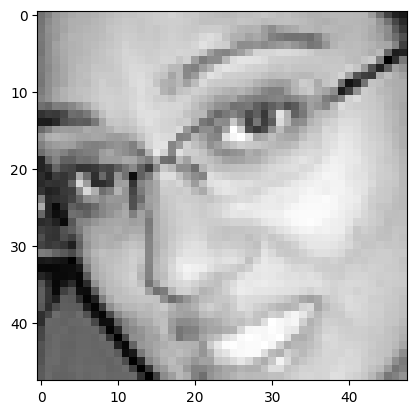

In [24]:
plt.imshow(img)